Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Output folder created:
   /content/drive/MyDrive/2026_lecture/Medical_AI/1week/output/run_20260310_065245
📂 폴더 구조 분석
✅ 감지된 클래스 수: 10
  [Avulsion fracture             ]   123 이미지
  [Comminuted fracture           ]   148 이미지
  [Fracture Dislocation          ]   156 이미지
  [Greenstick fracture           ]   122 이미지
  [Hairline Fracture             ]   111 이미지
  [Impacted fracture             ]    84 이미지
  [Longitudinal fracture         ]    80 이미지
  [Oblique fracture              ]    85 이미지
  [Pathological fracture         ]   134 이미지
  [Spiral Fracture               ]    86 이미지
------------------------------------------------------------
  TOTAL                           1129 이미지


/tmp/ipykernel_419/2600012948.py:82: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_419/2600012948.py:84: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig(sample_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


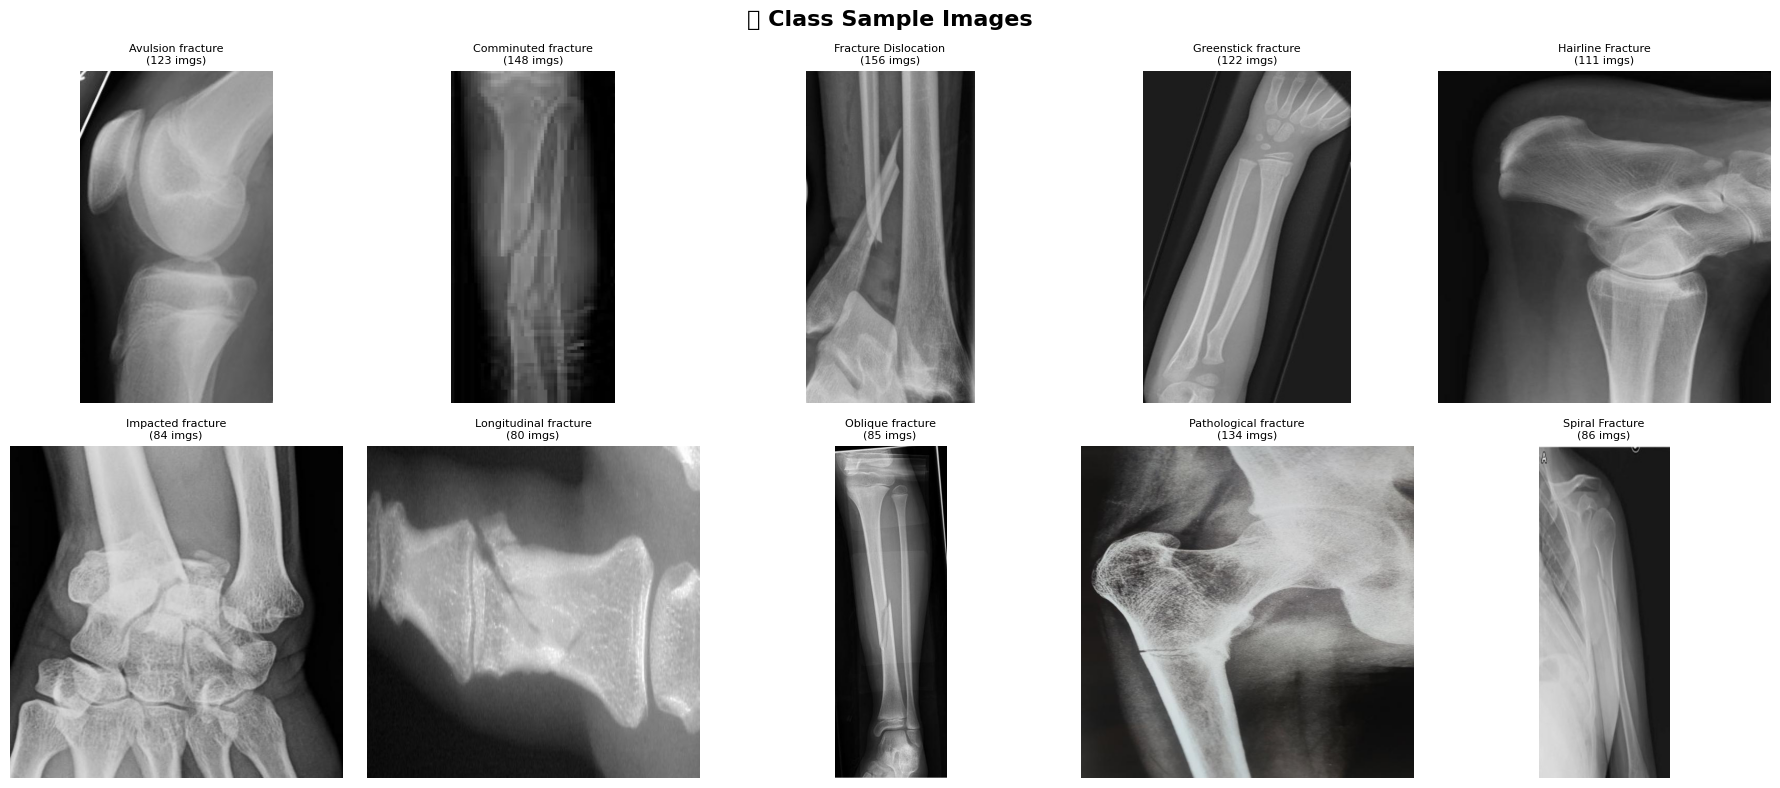

💾 샘플 이미지 저장: /content/drive/MyDrive/2026_lecture/Medical_AI/1week/output/run_20260310_065245/00_sample_images.png


/tmp/ipykernel_419/2600012948.py:99: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_419/2600012948.py:101: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(dist_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


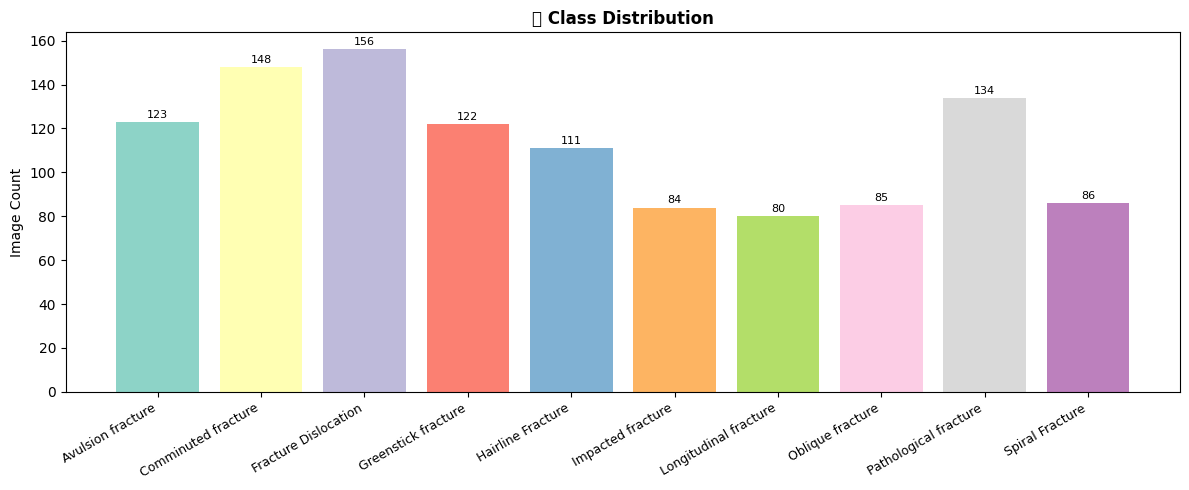

💾 분포 차트 저장: /content/drive/MyDrive/2026_lecture/Medical_AI/1week/output/run_20260310_065245/01_class_distribution.png
⚡ Device: cpu

📦 데이터셋 분할:
   Train :   903
   Val   :   112
   Test  :   114


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


🧠 Model: efficientnet_b3
   Total  params: 10,711,602
   Trainable    : 10,711,602

🚀 학습 시작!


Epoch 01 [Train]:   0%|          | 0/29 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 🦴 Bone Fracture 10-Class Classification
# Google Colab Code | Transfer Learning (EfficientNet-B3)
# ============================================================

# ────────────────────────────────────────────────────────────
# CELL 1: 라이브러리 설치 및 Google Drive 마운트
# ────────────────────────────────────────────────────────────
# !pip install -q torchvision timm matplotlib seaborn scikit-learn tqdm pillow

from google.colab import drive
drive.mount('/content/drive')

# ────────────────────────────────────────────────────────────
# CELL 2: 경로 설정
# ────────────────────────────────────────────────────────────
import os
from datetime import datetime

# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH  = "/content/drive/MyDrive/2026_lecture/Medical_AI/Medical_Imagining/Bone Break Classification"
OUTPUT_BASE = "/content/drive/MyDrive/2026_lecture/Medical_AI/1week/output"

# 매 실행마다 타임스탬프 기반 새 폴더 생성
RUN_STAMP   = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_PATH = os.path.join(OUTPUT_BASE, f"run_{RUN_STAMP}")
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f"✅ Output folder created:\n   {OUTPUT_PATH}")

# ────────────────────────────────────────────────────────────
# CELL 3: 폴더 구조 및 샘플 분석
# ────────────────────────────────────────────────────────────
import pathlib
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif', '.webp'}

print("=" * 60)
print("📂 폴더 구조 분석")
print("=" * 60)

class_names = sorted([
    d for d in os.listdir(INPUT_PATH)
    if os.path.isdir(os.path.join(INPUT_PATH, d))
])
print(f"✅ 감지된 클래스 수: {len(class_names)}")

total_images = 0
class_counts = {}
sample_images = {}  # 각 클래스의 첫 번째 이미지 경로

for cls in class_names:
    cls_dir = os.path.join(INPUT_PATH, cls)
    imgs = [
        f for f in pathlib.Path(cls_dir).rglob("*")
        if f.suffix.lower() in IMG_EXTS
    ]
    count = len(imgs)
    class_counts[cls] = count
    total_images += count
    if imgs:
        sample_images[cls] = str(imgs[0])
    print(f"  [{cls:30s}] {count:5d} 이미지")

print("-" * 60)
print(f"  {'TOTAL':30s} {total_images:5d} 이미지")

# 클래스별 샘플 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("📸 Class Sample Images", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, cls in enumerate(class_names):
    if cls in sample_images:
        img = Image.open(sample_images[cls]).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"{cls}\n({class_counts[cls]} imgs)", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
sample_path = os.path.join(OUTPUT_PATH, "00_sample_images.png")
plt.savefig(sample_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 샘플 이미지 저장: {sample_path}")

# 클래스 분포 바 차트
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(class_names)), [class_counts[c] for c in class_names],
              color=plt.cm.Set3.colors[:len(class_names)])
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Image Count")
ax.set_title("📊 Class Distribution", fontweight='bold')
for bar, cls in zip(bars, class_names):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(class_counts[cls]), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
dist_path = os.path.join(OUTPUT_PATH, "01_class_distribution.png")
plt.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 분포 차트 저장: {dist_path}")

# ────────────────────────────────────────────────────────────
# CELL 4: 하이퍼파라미터 & 데이터 로더
# ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
import numpy as np

# ── 하이퍼파라미터 ─────────────────────────────────────────
CFG = {
    "model_name"  : "efficientnet_b3",  # timm 모델명
    "img_size"    : 300,
    "batch_size"  : 32,
    "num_epochs"  : 30,
    "lr"          : 1e-4,
    "weight_decay": 1e-4,
    "train_ratio" : 0.8,
    "val_ratio"   : 0.1,
    "test_ratio"  : 0.1,
    "num_workers" : 2,
    "seed"        : 42,
    "num_classes" : len(class_names),
    "patience"    : 7,      # Early stopping patience
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"⚡ Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# 재현성 고정
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

# ── 데이터 증강 ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── 커스텀 Dataset (다양한 이미지 확장자 지원) ──────────────
from torchvision.datasets import ImageFolder

class MultiExtImageFolder(ImageFolder):
    """png/jpg/jpeg/bmp/tiff 등 모든 이미지 포맷 지원"""
    def is_valid_file(self, path):
        return pathlib.Path(path).suffix.lower() in IMG_EXTS

# 전체 데이터셋 로드 (경로만, transform 없이 길이 파악용)
full_dataset = MultiExtImageFolder(root=INPUT_PATH)
n = len(full_dataset)
n_train = int(n * CFG["train_ratio"])
n_val   = int(n * CFG["val_ratio"])
n_test  = n - n_train - n_val

# 인덱스 분리
indices = list(range(n))
np.random.shuffle(indices)
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

from torch.utils.data import Subset

train_ds = Subset(MultiExtImageFolder(root=INPUT_PATH, transform=train_transform), train_idx)
val_ds   = Subset(MultiExtImageFolder(root=INPUT_PATH, transform=val_transform),   val_idx)
test_ds  = Subset(MultiExtImageFolder(root=INPUT_PATH, transform=val_transform),   test_idx)

print(f"\n📦 데이터셋 분할:")
print(f"   Train : {len(train_ds):5d}")
print(f"   Val   : {len(val_ds):5d}")
print(f"   Test  : {len(test_ds):5d}")

# 클래스 불균형 처리 → WeightedRandomSampler
labels_train = [full_dataset.targets[i] for i in train_idx]
class_sample_count = np.array([labels_train.count(i) for i in range(CFG["num_classes"])])
weights = 1.0 / np.maximum(class_sample_count, 1)
sample_weights = np.array([weights[l] for l in labels_train])
sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          sampler=sampler, num_workers=CFG["num_workers"],
                          pin_memory=(DEVICE == "cuda"))
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"])
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"])

# ────────────────────────────────────────────────────────────
# CELL 5: 모델 정의 (EfficientNet-B3 Fine-tuning)
# ────────────────────────────────────────────────────────────
import timm

model = timm.create_model(
    CFG["model_name"],
    pretrained=True,
    num_classes=CFG["num_classes"]
)
model = model.to(DEVICE)

# 파라미터 수 출력
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🧠 Model: {CFG['model_name']}")
print(f"   Total  params: {total_params:,}")
print(f"   Trainable    : {train_params:,}")

# ── 손실함수 & 옵티마이저 ──────────────────────────────────
# 클래스 가중치 반영한 CrossEntropyLoss
class_weights_tensor = torch.tensor(weights / weights.sum() * CFG["num_classes"],
                                    dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"], weight_decay=CFG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["num_epochs"], eta_min=1e-6
)

# ────────────────────────────────────────────────────────────
# CELL 6: 학습 루프
# ────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  []
}

best_val_acc   = 0.0
patience_count = 0

print("\n🚀 학습 시작!")
print("=" * 65)

for epoch in range(1, CFG["num_epochs"] + 1):

    # ── Train ──────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d} [Train]", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        t_loss    += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        t_correct += (preds == labels).sum().item()
        t_total   += imgs.size(0)

    # ── Validation ─────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch:02d} [Val]  ", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            v_loss    += loss.item() * imgs.size(0)
            preds      = outputs.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total   += imgs.size(0)

    train_loss = t_loss / t_total
    val_loss   = v_loss / v_total
    train_acc  = t_correct / t_total * 100
    val_acc    = v_correct / v_total * 100
    lr_now     = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step()

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_count = 0
        best_ckpt = os.path.join(OUTPUT_PATH, "best_model.pth")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "class_names": class_names,
            "cfg": CFG,
        }, best_ckpt)
        flag = "  ⭐ Best!"
    else:
        patience_count += 1

    print(f"Epoch {epoch:02d}/{CFG['num_epochs']} | "
          f"LR: {lr_now:.2e} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%"
          f"{flag}")

    if patience_count >= CFG["patience"]:
        print(f"\n⏹️  Early stopping at epoch {epoch} (patience={CFG['patience']})")
        break

print(f"\n✅ 학습 완료  |  Best Val Acc: {best_val_acc:.2f}%")

# ────────────────────────────────────────────────────────────
# CELL 7: 학습 곡선 저장
# ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)

ax1.plot(ep, history["train_loss"], label="Train", color="#2196F3", marker='o', markersize=3)
ax1.plot(ep, history["val_loss"],   label="Val",   color="#F44336", marker='o', markersize=3)
ax1.set_title("Loss Curve", fontweight='bold'); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history["train_acc"], label="Train", color="#2196F3", marker='o', markersize=3)
ax2.plot(ep, history["val_acc"],   label="Val",   color="#F44336", marker='o', markersize=3)
ax2.set_title("Accuracy Curve", fontweight='bold'); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(OUTPUT_PATH, "02_training_curve.png")
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 학습 곡선 저장: {curve_path}")

# ────────────────────────────────────────────────────────────
# CELL 8: 테스트 평가 (Confusion Matrix + Classification Report)
# ────────────────────────────────────────────────────────────
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
import seaborn as sns

# Best 모델 로드
checkpoint = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="🔍 Testing"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean() * 100
print(f"\n📊 Test Accuracy: {test_acc:.2f}%")

# ── Confusion Matrix ────────────────────────────────────────
short_names = [c.replace(" fracture", "").replace(" Fracture", "") for c in class_names]
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title(f"Confusion Matrix  (Test Acc: {test_acc:.2f}%)", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
cm_path = os.path.join(OUTPUT_PATH, "03_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Confusion Matrix 저장: {cm_path}")

# ── Classification Report ───────────────────────────────────
report = classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4)
print("\n📋 Classification Report:")
print(report)

report_path = os.path.join(OUTPUT_PATH, "04_classification_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}%\n")
    f.write(f"Best Val Acc : {best_val_acc:.4f}%\n\n")
    f.write(report)
print(f"💾 Report 저장: {report_path}")

# ────────────────────────────────────────────────────────────
# CELL 9: Per-Class Accuracy 바 차트
# ────────────────────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4CAF50' if a >= 80 else '#FF9800' if a >= 60 else '#F44336'
          for a in per_class_acc]
bars = ax.bar(range(len(class_names)), per_class_acc, color=colors)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Test Accuracy", fontweight='bold')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% line')
ax.set_ylim(0, 115)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{acc:.1f}%", ha='center', va='bottom', fontsize=8)
ax.legend()
plt.tight_layout()
peracc_path = os.path.join(OUTPUT_PATH, "05_per_class_accuracy.png")
plt.savefig(peracc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Per-Class Accuracy 저장: {peracc_path}")

# ────────────────────────────────────────────────────────────
# CELL 10: 설정 및 결과 요약 저장
# ────────────────────────────────────────────────────────────
import json

summary = {
    "run_timestamp"   : RUN_STAMP,
    "model"           : CFG["model_name"],
    "num_classes"     : CFG["num_classes"],
    "class_names"     : class_names,
    "input_path"      : INPUT_PATH,
    "output_path"     : OUTPUT_PATH,
    "dataset_total"   : total_images,
    "train_samples"   : len(train_ds),
    "val_samples"     : len(val_ds),
    "test_samples"    : len(test_ds),
    "best_val_acc_pct": round(best_val_acc, 4),
    "test_acc_pct"    : round(test_acc, 4),
    "epochs_trained"  : len(history["train_loss"]),
    "hyperparams"     : CFG,
    "per_class_acc"   : {cls: round(float(acc), 2)
                         for cls, acc in zip(class_names, per_class_acc)},
}

summary_path = os.path.join(OUTPUT_PATH, "06_run_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"\n{'='*60}")
print(f"🎉 모든 결과 저장 완료!")
print(f"{'='*60}")
print(f"📁 Output folder : {OUTPUT_PATH}")
print(f"   ├─ 00_sample_images.png")
print(f"   ├─ 01_class_distribution.png")
print(f"   ├─ 02_training_curve.png")
print(f"   ├─ 03_confusion_matrix.png")
print(f"   ├─ 04_classification_report.txt")
print(f"   ├─ 05_per_class_accuracy.png")
print(f"   ├─ 06_run_summary.json")
print(f"   └─ best_model.pth")
print(f"{'='*60}")
print(f"✅ Best Val Acc : {best_val_acc:.2f}%")
print(f"✅ Test Acc     : {test_acc:.2f}%")